In [4]:
import ipywidgets as widgets
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from matplotlib.widgets import Slider

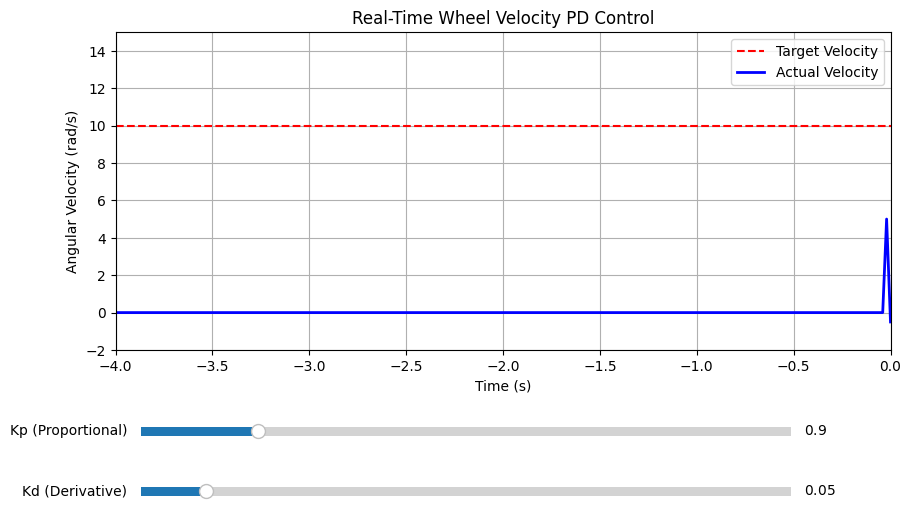

In [6]:
# --- System Parameters (Simulated Wheel) ---
J = 0.02  # Moment of inertia (kg*m^2)
b = 0.1  # Viscous friction coefficient (N*m*s)

# --- Simulation Variables ---
dt = 0.02  # Time step (50 Hz control loop)
history_len = 200  # Number of points to display
t_data = np.linspace(-history_len * dt, 0, history_len)
w_data = np.zeros(history_len)
target_data = np.ones(history_len) * 10.0  # Target velocity: 10 rad/s

# Initial state
current_w = 0.0
prev_error = 10.0

# --- Setup Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(bottom=0.35)  # Make room for sliders

ax.set_title("Real-Time Wheel Velocity PD Control")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular Velocity (rad/s)")
ax.set_xlim([-history_len * dt, 0])
ax.set_ylim([-2, 15])
ax.grid(True)

(line_target,) = ax.plot(t_data, target_data, "r--", label="Target Velocity")
(line_w,) = ax.plot(t_data, w_data, "b-", linewidth=2, label="Actual Velocity")
ax.legend(loc="upper right")

# --- Sliders for Kp and Kd ---
axcolor = "lightgoldenrodyellow"
ax_kp = plt.axes([0.15, 0.2, 0.65, 0.03], facecolor=axcolor)
ax_kd = plt.axes([0.15, 0.1, 0.65, 0.03], facecolor=axcolor)

s_kp = Slider(ax_kp, "Kp (Proportional)", 0.0, 5.0, valinit=0.9, valstep=0.1)
s_kd = Slider(ax_kd, "Kd (Derivative)", 0.0, 0.5, valinit=0.05, valstep=0.01)


# --- Update Function for Animation ---
def update(frame):
    global current_w, prev_error

    Kp = s_kp.val
    Kd = s_kd.val
    target_w = 10.0

    # 1. Calculate Error
    error = target_w - current_w

    # 2. Calculate Derivative of Error
    error_dot = (error - prev_error) / dt

    # 3. Control Law (Torque command)
    torque = (Kp * error) + (Kd * error_dot)

    # Optional: Saturation limit for a realistic motor
    torque = np.clip(torque, -5.0, 5.0)

    # 4. Plant Dynamics: angular acceleration (alpha)
    # J * alpha = torque - friction
    alpha = (torque - b * current_w) / J

    # 5. Euler Integration for new velocity
    current_w += alpha * dt
    prev_error = error

    # Update data arrays for plotting
    w_data[:-1] = w_data[1:]
    w_data[-1] = current_w

    line_w.set_ydata(w_data)
    return (line_w,)


# Run the animation
ani = animation.FuncAnimation(fig, update, interval=20, blit=True, save_count=50)
plt.show()

In [5]:
# --- System Parameters (Simulated Wheel) ---
J = 0.02  # Moment of inertia (kg*m^2)
b = 0.1  # Viscous friction coefficient (N*m*s)

# --- Simulation Setup ---
dt = 0.01  # Time step
t_end = 2.0  # Simulate for 2 seconds
time = np.arange(0, t_end, dt)
target_w = 10.0  # Target velocity: 10 rad/s


def simulate_pd_response(Kp, Kd):
    """Calculates and plots the step response for given Kp and Kd."""
    w_data = np.zeros_like(time)
    current_w = 0.0
    prev_error = target_w - current_w  # Initial error

    # Run the simulation loop over the time array
    for i in range(len(time)):
        # 1. Calculate Error
        error = target_w - current_w

        # 2. Calculate Derivative of Error
        error_dot = (error - prev_error) / dt

        # 3. Control Law (Torque command)
        torque = (Kp * error) + (Kd * error_dot)

        # Saturation limit for a realistic motor
        torque = np.clip(torque, -5.0, 5.0)

        # 4. Plant Dynamics
        alpha = (torque - b * current_w) / J

        # 5. Integration
        current_w += alpha * dt
        prev_error = error

        # Store data
        w_data[i] = current_w

    # --- Plotting ---
    plt.figure(figsize=(10, 5))
    plt.plot(time, np.ones_like(time) * target_w, "r--", label="Target Velocity")
    plt.plot(time, w_data, "b-", linewidth=2, label="Actual Velocity")

    plt.title(f"PD Control Step Response (Kp={Kp:.2f}, Kd={Kd:.3f})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angular Velocity (rad/s)")
    plt.ylim([-2, 15])
    plt.grid(True)
    plt.legend(loc="lower right")
    plt.show()


# --- Create the Interactive UI ---
interactive_plot = widgets.interact(
    simulate_pd_response,
    Kp=widgets.FloatSlider(
        value=0.5, min=0.0, max=5.0, step=0.1, description="Kp (Spring):", layout={"width": "500px"}
    ),
    Kd=widgets.FloatSlider(
        value=0.05, min=0.0, max=0.5, step=0.01, description="Kd (Damper):", layout={"width": "500px"}
    ),
)

interactive(children=(FloatSlider(value=0.5, description='Kp (Spring):', layout=Layout(width='500px'), max=5.0…

In [11]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

# --- System Parameters ---
m = 1.0  # Mass of the robot/cart (kg)
dt = 0.01  # Time step (s)
t_end = 20.0  # Simulation seconds
time = np.arange(0, t_end, dt)
target_pos = 10.0  # Target position: 10 meters


def simulate_pd_position(Kp, Kd):
    """Calculates and plots the step response for position control."""
    positions = np.zeros_like(time)
    velocities = np.zeros_like(time)
    forces = np.zeros_like(time)

    # Initial conditions (starting at rest at position 0)
    x = 0.0
    v = 0.0

    # Run the simulation loop
    for i in range(len(time)):
        # 1. Calculate Error (Distance to target)
        error = target_pos - x

        # 2. Calculate Derivative of Error
        # Since the target is not moving, the rate of change of the error
        # is just the negative of our current velocity.
        error_dot = -v

        # 3. Control Law (Calculate Force)
        # Kp acts as a spring, Kd acts as a damper
        force = (Kp * error) + (Kd * error_dot)

        # Realistic hardware limit: Motor can only output a max of 50 Newtons
        force = np.clip(force, -50.0, 50.0)

        # 4. Physics Engine: F = m*a  => a = F/m
        accel = force / m

        # 5. Euler Integration to update velocity and position
        v += accel * dt
        x += v * dt

        # Store data for plotting
        positions[i] = x
        velocities[i] = v
        forces[i] = force

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [2, 1]})

    # Plot 1: Position
    ax1.plot(time, np.ones_like(time) * target_pos, "r--", label="Target Position (10m)")
    ax1.plot(time, positions, "b-", linewidth=2, label="Actual Position")
    ax1.set_title(f"Position Control | Spring Pull (Kp) = {Kp}, Damping (Kd) = {Kd}")
    ax1.set_ylabel("Position (meters)")
    ax1.set_ylim(-2, 20)
    ax1.grid(True)
    ax1.legend(loc="lower right")

    # Plot 2: Control Effort (Force)
    ax2.plot(time, forces, "g-", linewidth=1.5, label="Motor Force Applied")
    ax2.set_ylabel("Force (Newtons)")
    ax2.set_xlabel("Time (seconds)")
    ax2.set_ylim(-55, 55)
    ax2.grid(True)
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


# --- Create the Interactive UI ---
widgets.interact(
    simulate_pd_position,
    Kp=widgets.FloatSlider(
        value=2.0, min=0.0, max=20.0, step=0.01, description="Kp (Spring):", layout={"width": "500px"}
    ),
    Kd=widgets.FloatSlider(
        value=0.5, min=0.0, max=10.0, step=0.1, description="Kd (Damper):", layout={"width": "500px"}
    ),
)

interactive(children=(FloatSlider(value=2.0, description='Kp (Spring):', layout=Layout(width='500px'), max=20.…

<function __main__.simulate_pd_position(Kp, Kd)>